# MSc Data Science: Identifying and Solving the Vanishing Gradient Problem
**Student:** Dennis Mburu Nganga  
**Student ID:** 24179558  
**Dataset:** UCI Dry Bean Dataset  

### 1. Introduction
In this tutorial, we explore the mechanics of deep neural networks. As we increase the depth of a Multilayer Perceptron (MLP) to capture complex patterns in tabular data, we often encounter a mathematical barrier known as the **Vanishing Gradient**.

This tutorial demonstrates:
1. How to diagnose a "frozen" model using gradient visualization.
2. Why the choice of activation function (Sigmoid vs. ReLU) is the difference between a model that learns and one that fails.
3. Professional data preprocessing and implementation using PyTorch.

In [12]:
# 1. ENVIRONMENT SETUP & DATA LOADING
from google.colab import drive
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import os

# Mount Google Drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Dry_Bean_Dataset.xlsx'

if os.path.exists(file_path):
    df = pd.read_excel(file_path, engine='openpyxl')
    print(f"✅ Dataset Loaded: {df.shape}")
else:
    print("❌ Error: File not found. Please check your Google Drive path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
❌ Error: File not found. Please check your Google Drive path.


### 2. Professional Pre-processing
Before feeding data into an MLP, we must address two things:
* **Label Encoding:** Converting categorical bean classes (e.g., 'Seker', 'Barbunya') into numerical format.
* **Standardization:** MLPs use gradient-based optimization. If one feature (like 'Area') has a range of 20,000 and another (like 'ShapeFactor1') is 0.001, the gradients will be dominated by the larger scale, causing instability. We use `StandardScaler` to ensure all features have a mean of 0 and a variance of 1.

In [13]:
# 2. DATA PRE-PROCESSING
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Convert to PyTorch Tensors for the Neural Network
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)

### 3. The Mathematics of Decay: Why Gradients Vanish
The update to our weights is calculated using the **Chain Rule**. For a 10-layer network, the gradient of the loss with respect to the first layer involves multiplying the derivatives of every subsequent activation function.

When using **Sigmoid** ($\sigma$), the maximum value of the derivative is **0.25**.
Multiplying 0.25 across 10 layers results in:
$$0.25^{10} \approx 0.00000095$$

This effectively rounds the "learning signal" to zero for the earliest layers. We will compare this against **ReLU** (Rectified Linear Unit), which has a derivative of **1.0** for all positive values, maintaining signal strength.

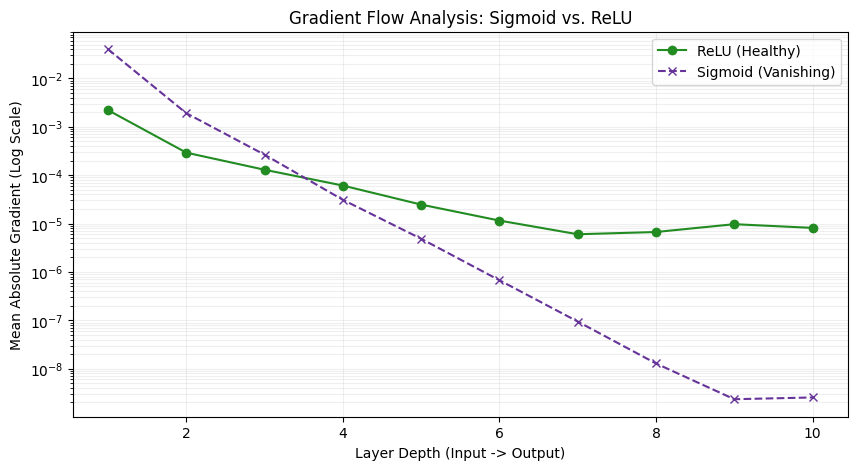

In [14]:
# 3. MODEL ARCHITECTURE & GRADIENT TRACKING
class DeepMLP(nn.Module):
    def __init__(self, activation_type="sigmoid"):
        super(DeepMLP, self).__init__()
        layers = []
        layers.append(nn.Linear(16, 64)) # Input Layer
        for _ in range(8): # 8 Hidden Layers
            layers.append(nn.Linear(64, 64))
            layers.append(nn.Sigmoid() if activation_type == "sigmoid" else nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.out = nn.Linear(64, 7) # Output Layer

    def forward(self, x):
        return self.out(self.hidden_layers(x))

def capture_gradients(model, x, y):
    model.train()
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()

    layer_grads = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            layer_grads.append(param.grad.abs().mean().item())
    return layer_grads

# Run the Experiment
sig_grads = capture_gradients(DeepMLP("sigmoid"), X_train_t[:256], y_train_t[:256])
relu_grads = capture_gradients(DeepMLP("relu"), X_train_t[:256], y_train_t[:256])

# Visualization
plt.figure(figsize=(10, 5))
layers = np.arange(1, len(sig_grads) + 1)
plt.plot(layers, relu_grads[::-1], label='ReLU (Healthy)', marker='o', color='#228B22')
plt.plot(layers, sig_grads[::-1], label='Sigmoid (Vanishing)', marker='x', color='#663399', linestyle='--')
plt.yscale('log')
plt.title("Gradient Flow Analysis: Sigmoid vs. ReLU")
plt.xlabel("Layer Depth (Input -> Output)")
plt.ylabel("Mean Absolute Gradient (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### 4. Conclusion and Professional Application
The visualization clearly shows that while the ReLU network maintains a consistent gradient magnitude, the Sigmoid network experiences a $10^5$ decrease in signal by the time it reaches the input layer.

**Key Takeaways for Data Science Practice:**
1. **Always monitor gradients** if your deep model fails to improve in accuracy.
2. **Default to ReLU** for deep hidden layers to ensure stable backpropagation.
3. **Architecture Matters:** Depth is only useful if the gradient can reach the "bottom" of the network.

### References
* Koklu, M. and Ozkan, I.A., (2020). "Multiclass Classification of Dry Beans..." *Computers and Electronics in Agriculture*.
* Glorot, X. and Bengio, Y., (2010). "Understanding the difficulty of training deep feedforward neural networks." *AISTATS*.
* He, K., et al. (2015). "Delving deep into rectifiers..." *ICCV*.